# 1. Κατεβάζουμε τα αρχεία

In [1]:
from gdown import download

download(id='10iQQcGN80wqRMjGeItnklsODP54hHydP', output='model_ferplus.pth', quiet=False)
download(id='1g56Vxvk506MV4mxf3489WI-KBgmKiRLw', output='angry.png', quiet=False)
download(id='1ej3OzvPL_Itck2v3Atln671l-RfrvCss', output='happy.png', quiet=False)
download(id='1-2C4lT5WdAXSleGOG0KHtTeYfyDonhJn', output='neutral.png', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10iQQcGN80wqRMjGeItnklsODP54hHydP
To: d:\projects\Supervised-Learning-Experiments\model_ferplus.pth
100%|██████████| 5.22M/5.22M [00:00<00:00, 5.67MB/s]
Downloading...
From: https://drive.google.com/uc?id=1g56Vxvk506MV4mxf3489WI-KBgmKiRLw
To: d:\projects\Supervised-Learning-Experiments\angry.png
100%|██████████| 15.3k/15.3k [00:00<00:00, 495kB/s]
Downloading...
From: https://drive.google.com/uc?id=1ej3OzvPL_Itck2v3Atln671l-RfrvCss
To: d:\projects\Supervised-Learning-Experiments\happy.png
100%|██████████| 7.18k/7.18k [00:00<00:00, 478kB/s]
Downloading...
From: https://drive.google.com/uc?id=1-2C4lT5WdAXSleGOG0KHtTeYfyDonhJn
To: d:\projects\Supervised-Learning-Experiments\neutral.png
100%|██████████| 5.85k/5.85k [00:00<00:00, 649kB/s]


'neutral.png'

# 2. Φορτώνουμε το μοντέλο

In [2]:
import torch
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

class ReshapeAndScale255(torch.nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x):
        if len(x.shape) == 2: x = x.unsqueeze(0)
        return ( x.unsqueeze(1) / 255 ).clamp(0,1)
model = torch.nn.Sequential(
    ReshapeAndScale255(),
    models.shufflenet_v2_x1_0(num_classes = 8)
)
model[1].conv1[0] = torch.nn.Conv2d(1, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
model[1].load_state_dict(torch.load('model_ferplus.pth', map_location=device))
model.eval()

emotion_labels = [
    "neutral",    # 0
    "happy",      # 1
    "surprise",   # 2
    "sad",        # 3
    "angry",      # 4
    "disgust",    # 5
    "fear",       # 6
    "contempt"    # 7
]

# 3. Φορτώνουμε τη φωτογραφία σαν torch.tensor και τις βοηθητικές συναρτήσεις

Μια φωτογραφία αντιστοιχεί σε ένα πίνακα με 112 γραμμές και 112 στήλες.
Κάθε τιμή του πίνακα είναι από 0 εώς 255

- **loadImage**: Φορτώνει μια εικόνα όταν της δοθεί το path του αρχείου.  
- **tensorToImage**: Μετατρέπει ένα PyTorch `Tensor` σε κανονική εικόνα


tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


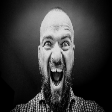

In [3]:
from PIL import Image
import numpy as np

def loadImage(filename):
    img = Image.open(filename).convert("L").resize( size=(112,112) )
    img_data = np.array(img).astype(np.float32)
    return torch.tensor(img_data)

def tensorToImage(tensor):
    return Image.fromarray(tensor.clamp(0,255).detach().reshape(112,112).numpy().astype(np.uint8))

Xoriginal = loadImage('angry.png')
print(Xoriginal)
tensorToImage(Xoriginal)

# 4. Αλλάζουμε τη φωτογραφία και βλέπουμε το καινούριο συναίσθημα

In [4]:
import torch
import torch.nn.functional as F
from time import perf_counter

def sparse_l1_attack(model, image, target_emotion, emotion_labels,
                     max_iters=500,
                     pixels_per_iter=1):
    t1 = perf_counter()

    model.eval()

    target_class = emotion_labels.index(target_emotion)
    adv = image.clone().detach().float()
    original = image.clone().detach().float()

    for iteration in range(max_iters):

        adv.requires_grad_(True)

        output = model(adv.clamp(0,255))
        pred_class = output.argmax(dim=1).item()
        pred_emotion = emotion_labels[pred_class]

        if (iteration % 100 == 0):
          print(f"Iteration {iteration}")
          probabilities = F.softmax(output, dim=1).squeeze()
          print("Model Confidence:")
          for emotion, probability in zip(emotion_labels, probabilities):
              print(f"{probability*100:8.1f}% - {emotion}")
          print(f"Predicted Emotion: {pred_emotion}")

        if pred_class == target_class:
            print(f"Attack succeeded at iteration {iteration}")
            print(f"Dt {perf_counter() - t1}")
            print(f"New emotion: {pred_emotion}")
            break

        loss = F.cross_entropy(output, torch.tensor([target_class]))
        model.zero_grad()
        loss.backward()

        grad = adv.grad.detach()

        # Create a detached copy for modifications to avoid in-place error
        adv_temp = adv.clone().detach()
        adv_temp_flat = adv_temp.view(-1)
        grad_flat = grad.view(-1)

        indices = torch.argsort(grad_flat.abs(), descending=True)

        changed = 0
        with torch.no_grad(): # Ensure these operations don't build a new graph
            for idx in indices:
                if changed >= pixels_per_iter:
                    break

                g = grad_flat[idx]
                if g == 0:
                    continue

                step = -1 if g > 0 else 1
                new_value = adv_temp_flat[idx] + step

                if 0 <= new_value <= 255:
                    adv_temp_flat[idx] = new_value
                    changed += 1

        adv = adv_temp.clone() # Reassign adv with the modified, detached tensor
        adv = adv.detach() # Detach for the next iteration's requires_grad

    distance = (original.round() - adv.round()).abs().sum().item()
    print(f"Final L1 distance = {distance}")
    print(f"Dt {perf_counter() - t1}")

    return adv

In [5]:
import torch
import torch.nn.functional as F

def generate_pair(model, image, target_emotion, emotion_labels,
                  max_iters=500, pixels_per_iter=1):

    model.eval()

    target_class = emotion_labels.index(target_emotion)

    adv = image.clone().detach().float()
    prev_adv = adv.clone().detach()
    original = image.clone().detach().float()

    for iteration in range(max_iters):
        adv.requires_grad_(True)

        output = model(adv.clamp(0,255))
        pred_class = output.argmax(dim=1).item()

        if (iteration % 100 == 0):
          print(f"Iteration {iteration}")
          probabilities = F.softmax(output, dim=1).squeeze()
          print("Model Confidence:")
          for emotion, probability in zip(emotion_labels, probabilities):
              print(f"{probability*100:8.1f}% - {emotion}")

        if pred_class == target_class:
            print(f"Boundary crossed at iteration {iteration}")
            break

        # Save previous state BEFORE modifying
        prev_adv = adv.clone().detach()

        loss = F.cross_entropy(output, torch.tensor([target_class]))
        model.zero_grad()
        loss.backward()

        grad = adv.grad.detach()

        # Create a detached copy for modifications to avoid in-place error
        adv_temp = adv.clone().detach()
        adv_temp_flat = adv_temp.view(-1)
        grad_flat = grad.view(-1)

        indices = torch.argsort(grad_flat.abs(), descending=True)

        changed = 0
        with torch.no_grad(): # Ensure these operations don't build a new graph
            for idx in indices:
                if changed >= pixels_per_iter:
                    break

                g = grad_flat[idx]
                if g == 0:
                    continue

                step = -1 if g > 0 else 1
                new_value = adv_temp_flat[idx] + step

                if 0 <= new_value <= 255:
                    adv_temp_flat[idx] = new_value
                    changed += 1

        adv = adv_temp.clone() # Reassign adv with the modified, detached tensor
        adv = adv.detach() # Detach for the next iteration's requires_grad

    # Compute exact L1 distance between the two submitted images
    distance = (prev_adv.round() - adv.round()).abs().sum().item()
    print(f"L1 distance between pair = {distance}")

    return prev_adv, adv

In [6]:
import torch
import torch.nn.functional as F

def untargeted_sparse_attack(model, image, emotion_labels,
                             max_iters=500,
                             pixels_per_iter=1):

    model.eval()

    adv = image.clone().detach().float()
    original = image.clone().detach().float()

    # Get original class (happy)
    with torch.no_grad():
        output = model(adv.clamp(0,255))
        true_class = output.argmax(dim=1)

    print("Original emotion:", emotion_labels[true_class.item()])

    prev_adv = adv.clone().detach()

    for iteration in range(max_iters):
        adv.requires_grad_(True)

        output = model(adv.clamp(0,255))
        pred_class = output.argmax(dim=1)

        if (iteration % 100 == 0):
          print(f"Iteration {iteration}")
          probabilities = F.softmax(output, dim=1).squeeze()
          print("Model Confidence:")
          for emotion, probability in zip(emotion_labels, probabilities):
              print(f"{probability*100:8.1f}% - {emotion}")

        # Stop when class changes
        if pred_class.item() != true_class.item():
            print(f"Class changed at iteration {iteration}")
            print("New emotion:", emotion_labels[pred_class.item()])
            break

        prev_adv = adv.clone().detach()

        loss = F.cross_entropy(output, true_class)
        model.zero_grad()
        loss.backward()

        grad = adv.grad.detach()

        # Create a detached copy for modifications to avoid in-place error
        adv_temp = adv.clone().detach()
        adv_temp_flat = adv_temp.view(-1)
        grad_flat = grad.view(-1)

        indices = torch.argsort(grad_flat.abs(), descending=True)

        changed = 0
        with torch.no_grad(): # Ensure these operations don't build a new graph
            for idx in indices:
                if changed >= pixels_per_iter:
                    break

                g = grad_flat[idx]
                if g == 0:
                    continue

                # IMPORTANT: push AWAY from true class
                step = 1 if g > 0 else -1

                new_value = adv_temp_flat[idx] + step

                if 0 <= new_value <= 255:
                    adv_temp_flat[idx] = new_value
                    changed += 1

        adv = adv_temp.clone() # Reassign adv with the modified, detached tensor
        adv = adv.detach() # Detach for the next iteration's requires_grad

    distance = (original.round() - adv.round()).abs().sum().item()
    print(f"Final L1 distance = {distance}")

    return prev_adv, adv

In [7]:
#TODO, παράδειγμα παρακάτω
easy_first = loadImage('neutral.png')
easy_second = loadImage('neutral.png')
easy_second[85:87,40:70] = 255

medium_first = loadImage('angry.png')
medium_second = loadImage('angry.png')


hard_first = loadImage('happy.png')
hard_second = loadImage('happy.png')

Η συνάρτηση `compare_images` θα σας βοηθήσει να βλέπετε γρήγορα τις 2 εικόνες μαζί με τις προβλέψεις του μοντέλου.

**ΣΗΜΑΝΤΙΚΟ!!**

Πριν περάσουν στο μοντέλο, οι εικόνες στρογγυλοποιούνται στα κοντινότερα ακέραια pixel values. Πχ, εάν ένα pixel έχει τιμή 225.3, τότε γίνεται 225.

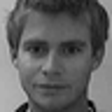

predictions A:
    98.6% - neutral
     0.3% - happy
     0.2% - surprise
     0.3% - sad
     0.2% - angry
     0.0% - disgust
     0.0% - fear
     0.4% - contempt
emotion A = neutral



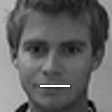

predictions B:
    30.8% - neutral
    65.7% - happy
     0.6% - surprise
     0.3% - sad
     0.4% - angry
     0.0% - disgust
     0.2% - fear
     2.1% - contempt
emotion B = happy

distance = 11851


In [8]:
def compare_images(A, B):
    predictionA = model(A.clamp(0,255).round()).squeeze().softmax(-1)
    predictionB = model(B.clamp(0,255).round()).squeeze().softmax(-1)

    display(tensorToImage(A))
    print("predictions A:")
    for emotion, probability in zip(emotion_labels, predictionA):
        print(f"{probability*100:8.1f}% - {emotion}")

    emotionA = emotion_labels[predictionA.argmax()]
    print(f"emotion A = {emotionA}\n")

    display(tensorToImage(B))
    print("predictions B:")
    for emotion, probability in zip(emotion_labels, predictionB):
        print(f"{probability*100:8.1f}% - {emotion}")

    emotionB = emotion_labels[predictionB.argmax()]
    print(f"emotion B = {emotionB}\n")

    distance = (A.round() - B.round()).abs().sum().int().item()
    print(f"distance = {distance}")


compare_images(easy_first, easy_second)

Iteration 0
Model Confidence:
    98.6% - neutral
     0.3% - happy
     0.2% - surprise
     0.3% - sad
     0.2% - angry
     0.0% - disgust
     0.0% - fear
     0.4% - contempt
Iteration 100
Model Confidence:
    84.9% - neutral
     6.2% - happy
     0.1% - surprise
     0.2% - sad
     0.1% - angry
     0.0% - disgust
     0.0% - fear
     8.5% - contempt
Iteration 200
Model Confidence:
    44.7% - neutral
    44.7% - happy
     0.0% - surprise
     0.1% - sad
     0.0% - angry
     0.0% - disgust
     0.0% - fear
    10.5% - contempt
Boundary crossed at iteration 200
L1 distance between pair = 2.0


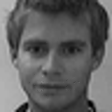

predictions A:
    45.3% - neutral
    43.8% - happy
     0.0% - surprise
     0.1% - sad
     0.0% - angry
     0.0% - disgust
     0.0% - fear
    10.7% - contempt
emotion A = neutral



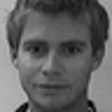

predictions B:
    44.7% - neutral
    44.7% - happy
     0.0% - surprise
     0.1% - sad
     0.0% - angry
     0.0% - disgust
     0.0% - fear
    10.5% - contempt
emotion B = happy

distance = 2


In [9]:
target_emotion = "happy"
target_class = emotion_labels.index(target_emotion)

easy_first, easy_second = generate_pair(model, easy_first, target_emotion, emotion_labels, max_iters=5000, pixels_per_iter=2) # emotion_labels

# The following line was adding a white rectangle; remove it to ensure easy_second is solely from the attack.
# easy_second[85:87,40:70] = 255
compare_images(easy_first, easy_second)

Iteration 0
Model Confidence:
     0.0% - neutral
     0.1% - happy
     9.5% - surprise
    18.2% - sad
    72.0% - angry
     0.0% - disgust
     0.1% - fear
     0.0% - contempt
Predicted Emotion: angry
Iteration 100
Model Confidence:
     0.0% - neutral
     1.1% - happy
    15.2% - surprise
    23.3% - sad
    60.2% - angry
     0.0% - disgust
     0.1% - fear
     0.0% - contempt
Predicted Emotion: angry
Iteration 200
Model Confidence:
     1.4% - neutral
     5.6% - happy
    20.9% - surprise
    22.3% - sad
    49.6% - angry
     0.0% - disgust
     0.1% - fear
     0.0% - contempt
Predicted Emotion: angry
Iteration 300
Model Confidence:
    10.1% - neutral
    16.9% - happy
    14.9% - surprise
    21.2% - sad
    36.9% - angry
     0.0% - disgust
     0.0% - fear
     0.0% - contempt
Predicted Emotion: angry
Iteration 400
Model Confidence:
    15.0% - neutral
    25.2% - happy
    12.5% - surprise
    18.6% - sad
    28.7% - angry
     0.0% - disgust
     0.0% - fear
     0.0

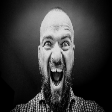

predictions A:
     0.0% - neutral
     0.1% - happy
     9.5% - surprise
    18.2% - sad
    72.0% - angry
     0.0% - disgust
     0.1% - fear
     0.0% - contempt
emotion A = angry



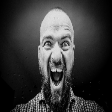

predictions B:
    14.6% - neutral
    27.5% - happy
    12.4% - surprise
    18.1% - sad
    27.4% - angry
     0.0% - disgust
     0.0% - fear
     0.0% - contempt
emotion B = happy

distance = 1880


In [10]:
target_emotion = "happy"
target_class = emotion_labels.index(target_emotion)

medium_second = sparse_l1_attack(model, medium_first, target_emotion, emotion_labels, max_iters=10000, pixels_per_iter=5) # emotion_labels

compare_images(medium_first, medium_second)

In [11]:
hard_first = loadImage('happy.png')
_, hard_first = untargeted_sparse_attack(model, hard_first, emotion_labels, 5000, 2)

Original emotion: happy
Iteration 0
Model Confidence:
     0.1% - neutral
    58.1% - happy
    34.4% - surprise
     0.1% - sad
     2.8% - angry
     0.0% - disgust
     4.6% - fear
     0.0% - contempt
Class changed at iteration 22
New emotion: surprise
Final L1 distance = 44.0


# 5. Αποθήκευση Απαντήσεων για υποβολή στο site

In [12]:
import json

def toList(tensor):
    return tensor.clamp(0,255).round().int().tolist()

answers = {
    "easy": {
        "first": toList(easy_first),
        "second": toList(easy_second)
    },
    "medium": {
        "second": toList(medium_second),
    },
    "hard": {
        "first": toList(hard_first),
    }
}
with open("answers.json", "w") as f:
    json.dump(answers, f)

In [13]:
from google.colab import files
files.download('answers.json')

ModuleNotFoundError: No module named 'google.colab'